### IMPORTATION DES BIBLIOTHEQUES ET PARAMETRES GLOBAUX

In [21]:
# ---  Préambule : imports ---
%matplotlib inline

import os, sys, importlib
from pathlib import Path
import ipynbname
import geopandas as gpd
import pandas as pd

# ---  Définition des chemins de base ---
base_path = Path(ipynbname.path()).parent.parent.parent  # racine du projet
path_data = base_path / 'Data'

# ---  Ajouter dossier scripts au Python path ---
scripts_path = base_path / 'Code' / 'Formatage'/'scripts'
sys.path.append(str(scripts_path.resolve()))

print("📌 **CONFIGURATION DES CHEMINS**")
print(f"📍 base_path    : {base_path}")
print(f"📂 path_data     : {path_data}")
print(f"📂 scripts_path  : {scripts_path}")


📌 **CONFIGURATION DES CHEMINS**
📍 base_path    : C:\Users\Aubin\Documents\MANTIS
📂 path_data     : C:\Users\Aubin\Documents\MANTIS\Data
📂 scripts_path  : C:\Users\Aubin\Documents\MANTIS\Code\Formatage\scripts


### CREATION DE LA GRILLE

In [70]:
# Paramètres pour l'importation des données géographiques et la création de la grille
geo_file = path_data/'SIG_global'/'world_boundaries.json'
geo_file = path_data/'SIG_global'/'communes-20220101-shp'/'Martigues+.shp'

zone="Martigues+"
name_attribute="nom"
code_attribute='nom'
cell_sizes_km=[0.1]
tolerance=0

# Créer le dossier (et les parents si nécessaire) s'il n'existe pas
output = path_data / "SIG_zone" / zone
output.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier créé ou existant : {output}")

📁 Dossier créé ou existant : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Martigues+


C:\Users\Aubin\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File C:\Users\Aubin\Documents\MANTIS\Data\SIG_global\communes-20220101-shp\Martigues+.shp has GPKG application_id, but non conformant file extension
  return ogr_read(


✔ Aucun doublon
📍 Grille enregistrée : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Martigues+\Martigues+_cellID_0.1km.geojson
✅ Grille pour 0.1 km générée et enregistrée avec clé cellID_0.1km


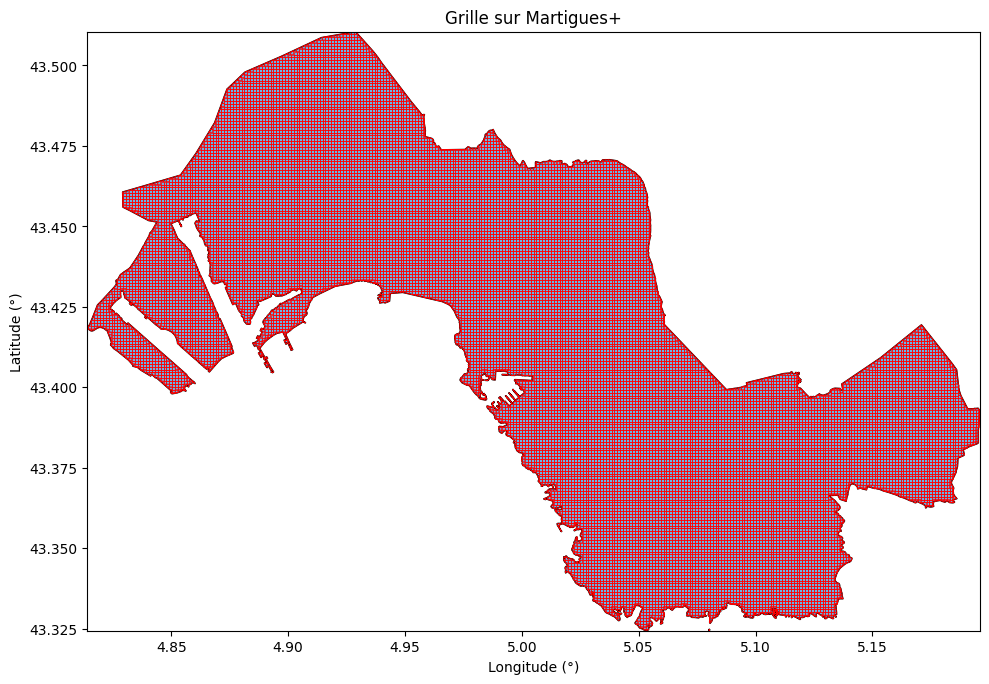

In [71]:
# Importer les fonctions
import formatage_geo
importlib.reload(formatage_geo)
from formatage_geo import generate_country_grid, plot_country_grid, simplify_world_geometry,save_country_grid

# Charger les données
geo_gdf = gpd.read_file(os.path.join(geo_file))

# Simplifier la géométrie
geo_gdf = simplify_world_geometry(geo_gdf, tolerance=tolerance)

# Générer les grilles et les sauvegarder
for cell_size_km in cell_sizes_km:
    cle_geo = f'cellID_{cell_size_km}km'
    grid = generate_country_grid(
        world_gdf=geo_gdf,
        country_name=zone,
        name_attribute=name_attribute,
        grid_size_km=cell_size_km,
        cle_geo=cle_geo,
        code_attribute=code_attribute
    )
    save_country_grid(grid, output, zone, cle_geo)
    print(f"✅ Grille pour {cell_size_km} km générée et enregistrée avec clé {cle_geo}")

# Afficher la dernière grille générée
plot_country_grid(geo_gdf, grid, name_attribute, zone)


### TRAITEMENT DES DONNEES BIODIV

In [74]:
# Paramètres pour l'importation et le nettoyage des données biodiversité
source = 'SILENE'                   # 'GBIF' or 'INPN'
zone = 'Martigues+'
cle_ID = "speciesID"              # Colonne identifiant les espèces
annee_min = 1950                  # Année minimale à conserver
chunksize = 10_000_000            # Taille des chunks pour la lecture


In [75]:
# Importer les fonctions
import formatage_biodiv
import importlib
importlib.reload(formatage_biodiv)
from formatage_biodiv import read_biodiv_chunks, save_clean_biodiv, inspect_columns_with_examples

# Définir le chemin du fichier source
path_fichier = path_data / source / 'raw' / f"{source}_{zone}.csv"

# Lire et nettoyer les données
print(f"📥 Lecture et nettoyage des données {source} pour {zone}...")

df_biodiv_clean = read_biodiv_chunks(
    path_fichier=path_fichier,
    source=source,
    cle_ID=cle_ID,
    annee_min=annee_min,
    chunksize=chunksize
)

# Sauvegarder les données nettoyées
print(f"💾 Sauvegarde des données nettoyées pour {zone}...")
save_clean_biodiv(df_biodiv_clean, source, zone, path_data)

# Afficher un aperçu des données nettoyées
print("\n📊 Informations sur les données nettoyées :")
print(df_biodiv_clean.info())

print("\n🖐 Quelques lignes d'exemple :")
display(df_biodiv_clean.head())

📥 Lecture et nettoyage des données SILENE pour Martigues+...
✅ Séparateur choisi : ',' avec 33 colonnes

--- Traitement chunk 1 ---
   🔧 Dates (année + mois valides)   -17 lignes (0.01%)
   🔧 clean coords                   -0 lignes (0.0%)
   🔧 clean ID                       -0 lignes (0.0%)
   🔧 clean nombreObs                -0 lignes (0.0%)
✅ Chunk 1 traité. Total lignes cumulées : 121949

🎉 Lecture complète terminée : 121949 lignes
💾 Sauvegarde des données nettoyées pour Martigues+...
🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\SILENE\clean\SILENE_Martigues+.csv

📊 Informations sur les données nettoyées :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121949 entries, 0 to 121948
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   speciesID  121949 non-null  object 
 1   nombreObs  121949 non-null  int64  
 2   species    121949 non-null  object 
 3   genus      121949 non-null  o

,speciesID,nombreObs,species,genus,family,order,class,kingdom,month,year,lon,lat
0,110473,1,Ophrys speculum,Ophrys,Orchidaceae,Asparagales,Equisetopsida,Plantae,4,1999,5.167290,43.399400
1,92139,1,Colchicum filifolium,Colchicum,Colchicaceae,Liliales,Equisetopsida,Plantae,10,2001,5.025407,43.341259
2,127915,1,Tulipa agenensis,Tulipa,Liliaceae,Liliales,Equisetopsida,Plantae,3,2001,5.035244,43.368773
3,100543,1,Gomphocarpus fruticosus,Gomphocarpus,Apocynaceae,Gentianales,Equisetopsida,Plantae,11,2000,4.948828,43.439999
4,113230,1,Phleum subulatum,Phleum,Poaceae,Poales,Equisetopsida,Plantae,8,2000,5.119634,43.395663


### Obs to Grid

In [76]:
#Parameters
cell_size_km=0.1
cle_geo = f'cellID_{cell_size_km}km'

file_path_biodiv = path_data / source / 'clean' / f"{source}_{zone}.csv"

file_path_grid= path_data / 'SIG_zone' / zone / f"{zone}_{cle_geo}.geojson"

In [77]:
# Importer les fonctions
import formatage_ObsToGrid
importlib.reload(formatage_ObsToGrid)
from formatage_ObsToGrid import assign_grid_to_points,generate_taxo_dict,aggregate_by_grid_species, save_processed_biodiv

# Importation des données 
print(f"📥 Lecture du fichier nettoyé : {file_path_biodiv}")
df_biodiv_clean = pd.read_csv(file_path_biodiv,dtype={cle_ID: "string"})

print(f"📥 Lecture du fichier grille : {file_path_grid}")
grid = gpd.read_file(os.path.join(file_path_grid))

# Assigner la grille
df_with_grid = assign_grid_to_points(df_biodiv_clean, grid, cle_geo)

# Ajouter les noms vernaculaires
dico_noms_vernaculaires = pd.read_csv(path_data/"Taxonomie"/ "dico_noms_vernaculaires_merged.csv")

# Chargement des noms vernaculaires
df_with_grid = pd.merge(df_with_grid, dico_noms_vernaculaires, on=cle_ID, how="left")

# Générer le dictionnaire taxonomique
dico_taxo = generate_taxo_dict(df_with_grid, cle_ID=cle_ID)

# Agréger et fusionner avec le dictionnaire taxonomique
df_final = aggregate_by_grid_species(df_with_grid, cle_geo, dico_taxo, cle_ID=cle_ID)

# Sauvegarder le dataframe
save_processed_biodiv(df_final, source, zone, cle_geo,path_data)


📥 Lecture du fichier nettoyé : C:\Users\Aubin\Documents\MANTIS\Data\SILENE\clean\SILENE_Martigues+.csv
📥 Lecture du fichier grille : C:\Users\Aubin\Documents\MANTIS\Data\SIG_zone\Martigues+\Martigues+_cellID_0.1km.geojson
⏱ Temps estimé pour l'ensemble des points : 2.15 s (basé sur 1219 points)
✅ Temps réel pour l'opération complète : 0.13 s
➡️ 112487 points avec plusieurs cellules correspondantes
➡️ 23649 points sans cellule correspondante
🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\SILENE\processed\Martigues+\SILENE_Martigues+_cellID_0.1km.csv


WindowsPath('C:/Users/Aubin/Documents/MANTIS/Data/SILENE/processed/Martigues+/SILENE_Martigues+_cellID_0.1km.csv')

### Fusion

In [78]:
# Parameters
seuil_obs=100
seuil_species=20


C:\Users\Aubin\Documents\MANTIS\Code\Formatage\scripts\formatage_fusion.py:211: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


🔄 Fusion des cellules en cours...
22699 cellules restantes (90.0%), min nombreObs = 0.0, min_species = 0
20429 cellules restantes (81.0%), min nombreObs = 0.0, min_species = 0
18386 cellules restantes (72.9%), min nombreObs = 0.0, min_species = 0
16547 cellules restantes (65.6%), min nombreObs = 0.0, min_species = 0
14892 cellules restantes (59.0%), min nombreObs = 0.0, min_species = 0
13402 cellules restantes (53.1%), min nombreObs = 0.0, min_species = 0
12061 cellules restantes (47.8%), min nombreObs = 0.0, min_species = 0
10854 cellules restantes (43.0%), min nombreObs = 0.0, min_species = 0
9768 cellules restantes (38.7%), min nombreObs = 0.0, min_species = 0
8791 cellules restantes (34.9%), min nombreObs = 0.0, min_species = 0
7911 cellules restantes (31.4%), min nombreObs = 0.0, min_species = 0
7119 cellules restantes (28.2%), min nombreObs = 0.0, min_species = 0
6407 cellules restantes (25.4%), min nombreObs = 0.0, min_species = 0
5766 cellules restantes (22.9%), min nombreObs =

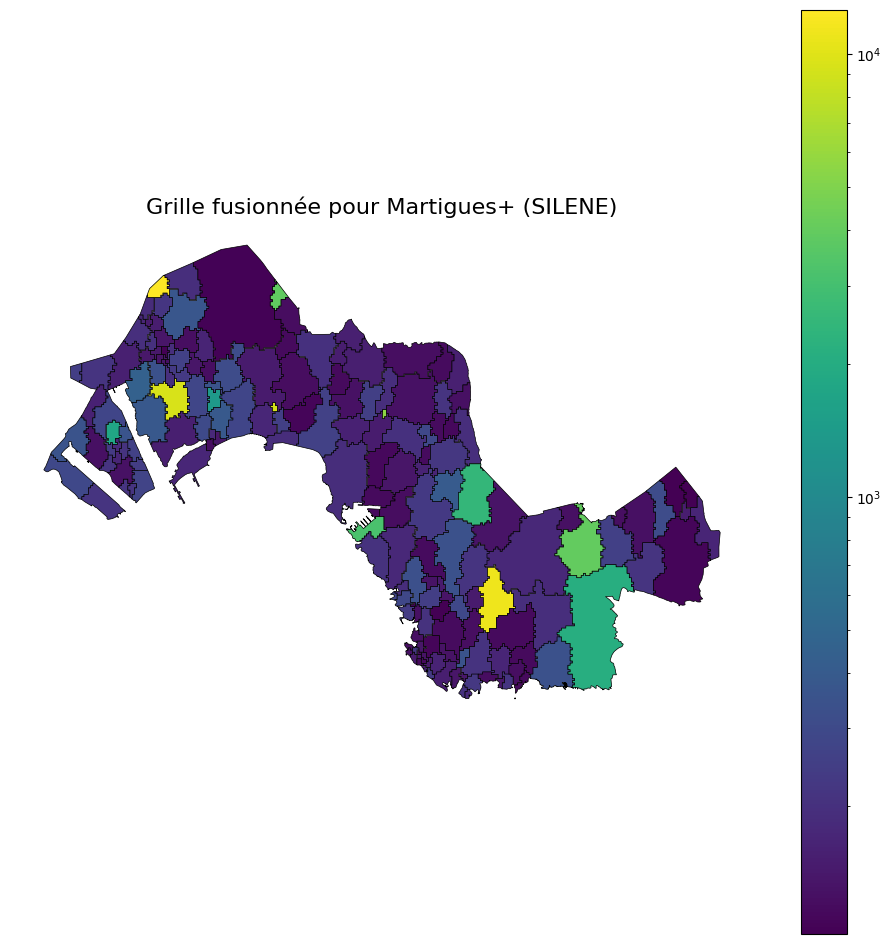

🎉 Données nettoyées sauvegardées dans : C:\Users\Aubin\Documents\MANTIS\Data\SILENE\processed\Martigues+\SILENE_Martigues+_cellID_0.1km_fused_minObs100_minSp20.csv


WindowsPath('C:/Users/Aubin/Documents/MANTIS/Data/SILENE/processed/Martigues+/SILENE_Martigues+_cellID_0.1km_fused_minObs100_minSp20.csv')

In [79]:
import formatage_fusion
importlib.reload(formatage_fusion)
from formatage_fusion import fusion_cells_by_obs,apply_fusion_to_biodiv,plot_fusionned_grid,save_fusionned_biodiv,save_merged_grid,fusion_cells_by_obs_and_species

# Fusion des cellules avec seuil 1000 observations
#merged_fusion = fusion_cells_by_obs(df_final, grid, cle_geo, var_obs='nombreObs', seuil=seuil_obs)
merged_fusion=fusion_cells_by_obs_and_species(df_final, grid, cle_geo, var_obs='nombreObs', seuil=seuil_obs,cle_ID=cle_ID, min_species=seuil_species, methode="barycentre")

save_merged_grid(merged_fusion, path_data, zone, cle_geo, source, seuil_obs,seuil_species)

# gdf_fusion est votre GeoDataFrame résultant de fusion_cells_by_obs
plot_fusionned_grid(merged_fusion, var_obs='nombreObs', title=f"Grille fusionnée pour {zone} ({source})", figsize=(12,12),log_scale=True)

# Appliquer les fusions sur le dataframe original et sauvegarder
df_biodiv_fusion = apply_fusion_to_biodiv(df_final, merged_fusion, cle_geo=cle_geo, cle_ID='speciesID', var_obs='nombreObs')

save_fusionned_biodiv(df_biodiv_fusion, source, zone, cle_geo, path_data,seuil_obs,seuil_species)
